# Kathmandu Rental Price Prediction



## 1. Load Data

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "nepal_rental_kathmandu_dataset.csv"

data = pd.read_csv(DATA_PATH)
df = data.copy()

print("Shape:", df.shape)
df.head()

Shape: (156, 24)


,listing_id,title,monthly_rent_npr,area_sqft_approx,road_width_ft,location,ward,municipality,district,property_type,...,living_rooms,kitchens,total_rooms,parking,built_up_sqft,no_of_flats,built_year,description,city,source
0,9541,House for rent,75000.0,1197.88,14.0,"Samakhusi 26 Kathmandu Metropolis Kathmandu, B...",26.0,Kathmandu Metropolis,Kathmandu,house,...,3.0,2.0,8.0,Car 1,2200.0,2.5,2072,Prime location. Posh area.,kathmandu,gharghaderi.com
1,9464,"House on rent: Civil Homes Phase VII, Nagarjun-6",50000.0,1026.75,10.0,"Sitapaila 6 Kathmandu Metropolis Kathmandu, Ba...",6.0,Kathmandu Metropolis,Kathmandu,house,...,1.0,1.0,5.0,Cars 3-5,850.0,2.0,2075,A well-maintained house on 2.5 anna land is av...,kathmandu,gharghaderi.com
2,9361,4 BHK Semi Furnished House for Rent at Bhaisepati,119999.0,1540.12,12.0,"Bhaisepati 18 Kathmandu Metropolis Kathmandu, ...",18.0,Kathmandu Metropolis,Kathmandu,house,...,1.0,1.0,5.0,Cars 2,1600.0,2.5,2070,4BHK Semi Furninsed house on rent at Bhaisepat...,kathmandu,gharghaderi.com
3,9087,House on Rent at Koteswor for Office or Restau...,250000.0,3935.88,26.0,"Koteswor 32 Kathmandu Metropolis Kathmandu, Ba...",32.0,Kathmandu Metropolis,Kathmandu,house,...,1.0,1.0,9.0,Cars 5-10,3100.0,2.5,2065,NaN,kathmandu,gharghaderi.com
4,9034,Fully-Furnished House on rent at Budhanilkantha,120000.0,1369.00,13.0,"Budhanilkantha Kathmandu Metropolis Kathmandu,...",NaN,Budhanilkantha Kathmandu Metropolis,Kathmandu,house,...,2.0,1.0,NaN,Car 1,NaN,NaN,Select Year,Fully-Furnished House on rent at Budhanilkanth...,kathmandu,gharghaderi.com


## 2. Exploratory Data Analysis (EDA)

In [5]:
print(df.dtypes)

listing_id            int64
title                   str
monthly_rent_npr    float64
area_sqft_approx    float64
road_width_ft       float64
location                str
ward                float64
municipality            str
district                str
property_type           str
house_type              str
direction               str
bedrooms            float64
bathrooms           float64
living_rooms        float64
kitchens            float64
total_rooms         float64
parking                 str
built_up_sqft       float64
no_of_flats         float64
built_year              str
description             str
city                    str
source                  str
dtype: object


In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

built_up_sqft       127
total_rooms         126
ward                 75
living_rooms         67
municipality         62
area_sqft_approx     39
house_type           38
kitchens             35
no_of_flats          34
road_width_ft        28
parking              23
description          12
bedrooms              8
bathrooms             3
dtype: int64


In [7]:
for col in ["property_type", "house_type", "direction", "parking", "city", "municipality"]:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== property_type =====
property_type
house         83
apartments    39
flats         34
Name: count, dtype: int64

===== house_type =====
house_type
Residential        73
NaN                38
Semi-commercial    16
Bungalow           11
Choose Type         7
Furnished           5
Commercial          4
Non-Furnished       1
Semi-furnished      1
Name: count, dtype: int64

===== direction =====
direction
East                42
South               36
Select Direction    22
West                22
North               16
South East           6
South West           3
South east           3
South west           3
North east           2
North East           1
Name: count, dtype: int64

===== parking =====
parking
Car 1         45
NaN           23
Motorbike     21
Motorcycle    16
Cars 2        14
Cars 3-5      13
Cars 5-10      8
Car 3-5        5
Cars 10-15     4
Car 2          4
Car 5-10       2
Car 5+         1
Name: count, dtype: int64

===== city =====
city
kathmandu    122
bhaktapur   

count    1.560000e+02
mean     9.981506e+05
std      5.232799e+06
min      8.000000e+03
25%      5.000000e+04
50%      9.250000e+04
75%      1.712500e+05
max      4.000000e+07
Name: monthly_rent_npr, dtype: float64


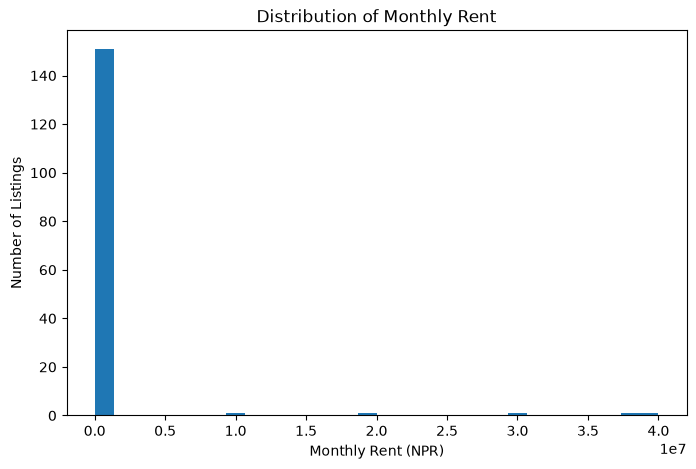

In [8]:
print(df["monthly_rent_npr"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["monthly_rent_npr"], bins=30)
plt.xlabel("Monthly Rent (NPR)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Monthly Rent")
plt.show()

## 3. Correlation Analysis

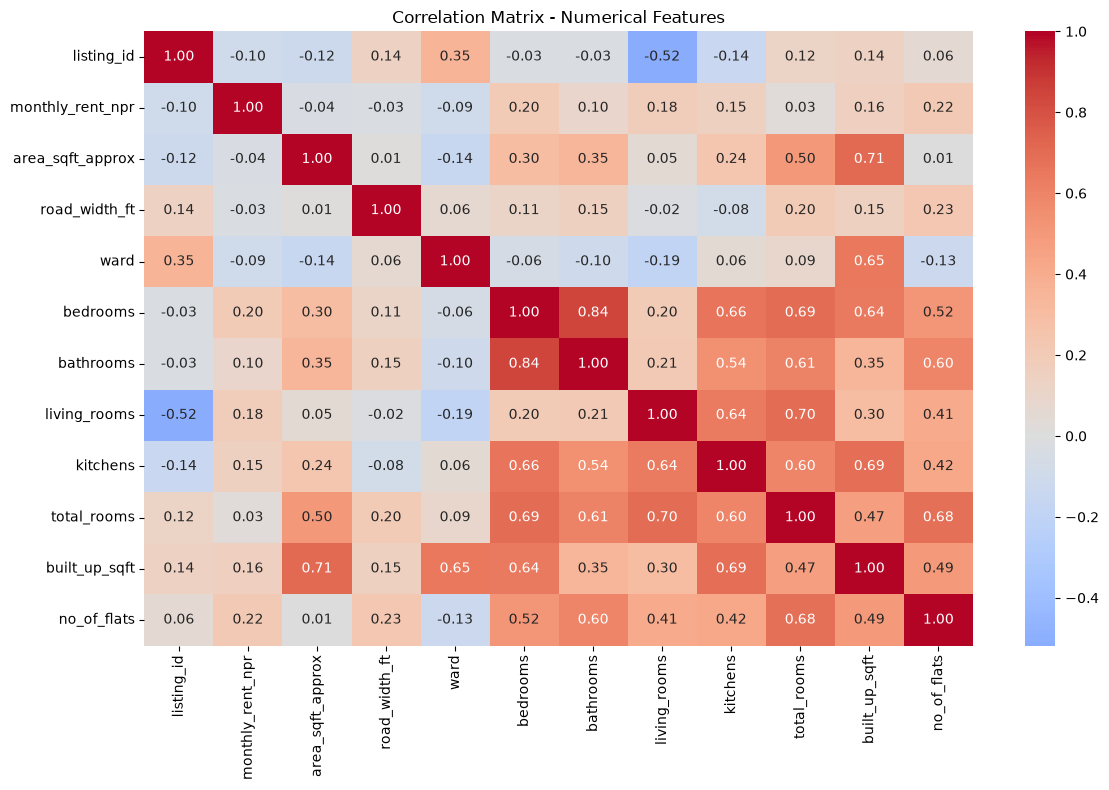

monthly_rent_npr    1.000000
no_of_flats         0.215620
bedrooms            0.201503
living_rooms        0.176452
built_up_sqft       0.163024
kitchens            0.146595
bathrooms           0.095347
total_rooms         0.028061
road_width_ft      -0.029298
area_sqft_approx   -0.037527
ward               -0.092425
listing_id         -0.096513
Name: monthly_rent_npr, dtype: float64


In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Numerical Features")
plt.tight_layout()
plt.show()

print(corr_matrix["monthly_rent_npr"].sort_values(ascending=False))

Bedrooms and bathrooms are the strongest numeric predictors of rent — bigger, better-equipped homes cost more. `area_sqft_approx` and `road_width_ft` are positively correlated but more weakly. `ward` is essentially uncorrelated (~-0.11), which makes sense since it's a location ID, not a magnitude.

## 4. Outlier Detection (Informational)

IQR-based outlier detection on the target and key numeric features. Outliers are flagged here for awareness, not automatically deleted — real listings that are genuinely just expensive or cheap contain useful signal, and the Section 6 data-cleaning step already handles clearly *invalid* records (data-entry errors, mislabeled sale listings).

In [13]:
outlier_cols = [
    "monthly_rent_npr", "area_sqft_approx", "road_width_ft",
    "bedrooms", "bathrooms", "living_rooms", "kitchens", "no_of_flats",
]

outlier_summary = []
for col in outlier_cols:
    if col not in df.columns:
        continue
    series = pd.to_numeric(df[col], errors="coerce").dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    outlier_summary.append({
        "column": col, "lower_bound": lower, "upper_bound": upper,
        "n_outliers": n_outliers, "pct_outliers": round(100 * n_outliers / len(series), 2),
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
print(outlier_summary_df.to_string(index=False))

          column  lower_bound  upper_bound  n_outliers  pct_outliers
monthly_rent_npr  -131875.000   353125.000          13          8.33
area_sqft_approx    -2224.625     7358.375          11          9.40
   road_width_ft        2.500       30.500           0          0.00
        bedrooms       -2.500        9.500           3          2.03
       bathrooms       -3.500        8.500           2          1.31
    living_rooms       -0.500        3.500          15         16.85
        kitchens        1.000        1.000          18         14.88
     no_of_flats       -1.250        4.750           2          1.64


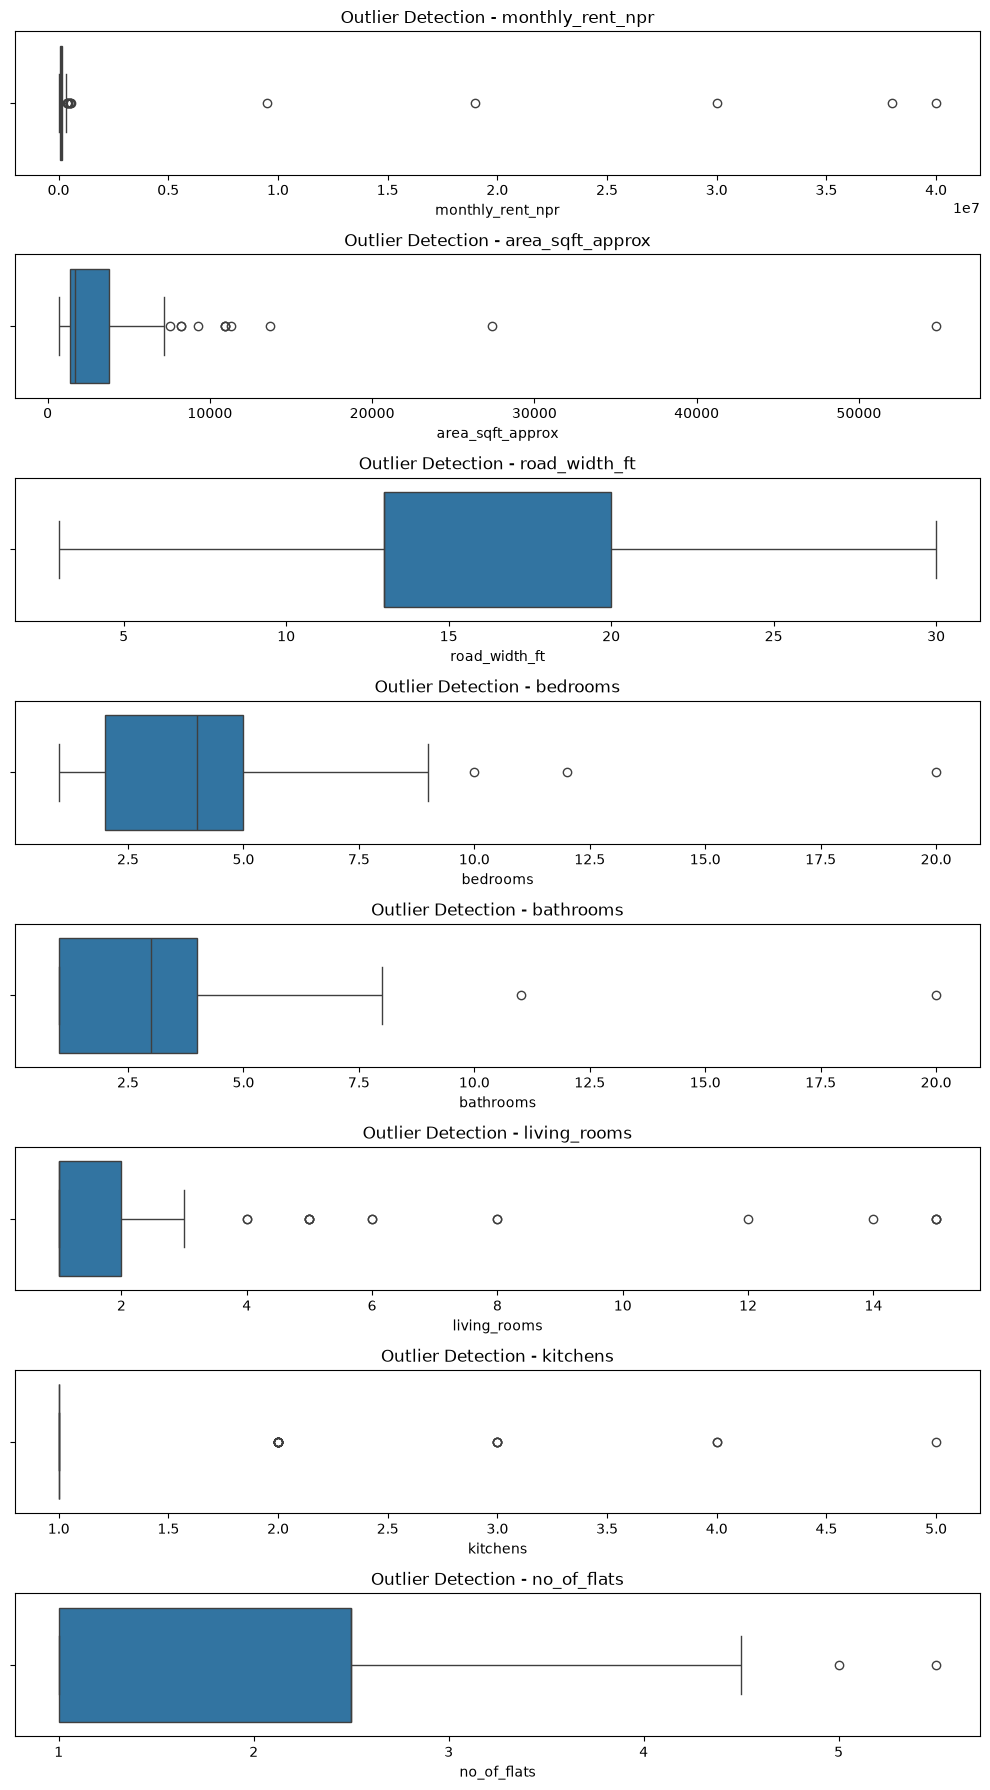

In [14]:
fig, axes = plt.subplots(nrows=len(outlier_cols), ncols=1, figsize=(10, 18))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(x=pd.to_numeric(df[col], errors="coerce"), ax=ax)
    ax.set_title(f"Outlier Detection - {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

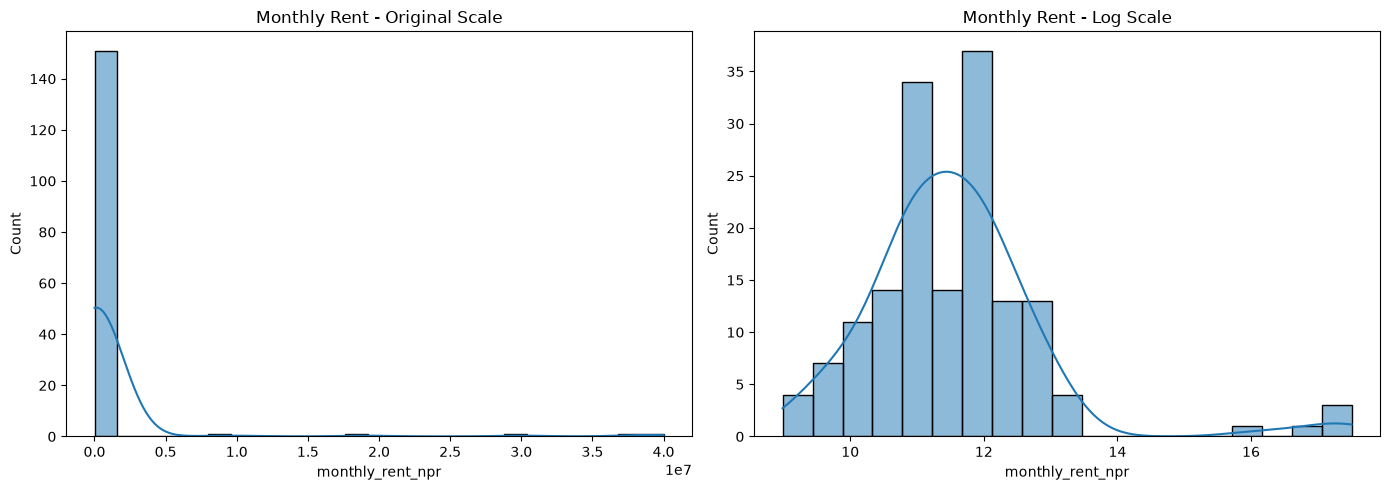

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["monthly_rent_npr"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Monthly Rent - Original Scale")
sns.histplot(np.log1p(df["monthly_rent_npr"].dropna()), kde=True, ax=axes[1])
axes[1].set_title("Monthly Rent - Log Scale")
plt.tight_layout()
plt.show()

The log-scale view is noticeably more symmetric than the raw scale — a sign that a log-transformed target is worth testing formally later on (Section 10).

## 5. Data Cleaning

### 5.1 City

In [19]:
df["city"] = df["city"].astype("string").str.strip().str.title()
df = df.drop(columns=["district"], errors="ignore")

### 5.2 Location

`location` is messy free text. We normalize it, strip the province/district suffix, strip trailing municipality names, and strip a trailing number when it matches the listing's `ward` (during EDA we found the trailing number is usually the ward, matching in about 74/156 rows where both are present).

In [21]:
df["location_raw"] = df["location"]

df["location_clean"] = (
    df["location_raw"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(r",\s*(bagmati|state 3)$", "", regex=True)
    .str.replace(r"\s+kathmandu$", "", regex=True)
    .str.strip()
)

municipality_names = [
    "kathmandu metropolis", "budhanilkantha", "nagarjun", "chandragiri",
    "kirtipur", "tarakeshwar", "tokha", "gokarna", "kageswori manohara",
    "lalitpur metropolis", "bhaktapur municipality",
]

df["location_locality"] = df["location_clean"]
for municipality in municipality_names:
    df["location_locality"] = (
        df["location_locality"]
        .str.replace(rf"\s+{municipality}$", "", regex=True)
        .str.strip()
    )

def remove_matching_ward(text, ward):
    if pd.isna(text) or pd.isna(ward):
        return text
    text = str(text).strip()
    return re.sub(rf"\s+{int(ward)}$", "", text).strip()

df["location_locality_clean"] = df.apply(
    lambda row: remove_matching_ward(row["location_locality"], row["ward"]),
    axis=1,
)

df[["location_raw", "location_locality_clean"]].head(10)

,location_raw,location_locality_clean
0,"Samakhusi 26 Kathmandu Metropolis Kathmandu, B...",samakhusi
1,"Sitapaila 6 Kathmandu Metropolis Kathmandu, Ba...",sitapaila
2,"Bhaisepati 18 Kathmandu Metropolis Kathmandu, ...",bhaisepati
3,"Koteswor 32 Kathmandu Metropolis Kathmandu, Ba...",koteswor
4,"Budhanilkantha Kathmandu Metropolis Kathmandu,...",budhanilkantha
5,"Bansbari-3 3 Kathmandu Metropolis Kathmandu, B...",bansbari-3
6,"Maitinagar Kathmandu Metropolis Kathmandu, Bag...",maitinagar
7,"Imadol Kathmandu Metropolis Kathmandu, Bagmati",imadol
8,"Kalanki Kathmandu Metropolis Kathmandu, Bagmati",kalanki
9,"Dhumbarahi Kathmandu Metropolis Kathmandu, Bag...",dhumbarahi


### 5.3 Fix / Remove Bad Rent Records

One listing has a rent value that is clearly a data-entry error, and several listings are actually property-sale posts (not rentals) — those are dropped in two passes: a set found by manually reviewing extreme rent values, and a broader regex sweep over title/description text.

In [23]:
# Known data-entry error
df.loc[df["listing_id"] == 7425, "monthly_rent_npr"] = 95000

# Manually identified sale listings (found while reviewing extreme rent values)
manual_sale_ids = [5911, 7548, 3372, 3096]
df = df[~df["listing_id"].isin(manual_sale_ids)].copy()
print("Rows after removing manually identified sale listings:", len(df))

# Flag remaining listings whose title/description indicate a sale rather than a rental
text_for_check = (
    df["title"].fillna("") + " " + df["description"].fillna("")
).str.lower()

sale_pattern = (
    r"\bfor sale\b|\bon sale\b|\bon sell\b|\bfor sell\b|"
    r"\bhouse on sale\b|\bflat for sale\b"
)
is_sale_listing = text_for_check.str.contains(sale_pattern, regex=True, na=False)

# listing 9464 only matches on an unrelated compound word - keep it as a rental
is_sale_listing.loc[df["listing_id"] == 9464] = False

print("Removing sale listings:", df.loc[is_sale_listing, "listing_id"].tolist())
df = df[~is_sale_listing].copy()

print("Rows remaining:", len(df))

Rows after removing manually identified sale listings: 152
Removing sale listings: [4209, 3806]
Rows remaining: 150


### 5.4 Extract Signals from Description Text

Before `description` gets dropped as a modeling column, pull two lightweight signals out of it: furnishing status and whether a garden/terrace/balcony is mentioned. These become an **experimental** feature set — Section 9 tests whether they actually improve predictions before deciding whether to keep them.

In [25]:
desc = df["description"].fillna("").str.lower()

df["furnishing_status"] = np.select(
    [
        desc.str.contains(r"\bsemi[\s-]?furnished\b", regex=True),
        desc.str.contains(r"\bunfurnished\b", regex=True),
        desc.str.contains(r"\bfurnished\b", regex=True),
    ],
    ["semi_furnished", "unfurnished", "furnished"],
    default="unknown",
)

df["has_garden"] = desc.str.contains(
    r"\bgarden\b|\bterrace\b|\bbalcony\b", regex=True
).astype(int)

print(df["furnishing_status"].value_counts())
print()
print(df["has_garden"].value_counts())

furnishing_status
unknown           79
furnished         53
semi_furnished    17
unfurnished        1
Name: count, dtype: int64

has_garden
0    118
1     32
Name: count, dtype: int64


### 5.5 Drop Columns Not Needed for Modeling

In [27]:
drop_cols = [
    "listing_id", "title", "description",
    "location", "location_raw", "location_clean", "location_locality",
    "built_up_sqft", "total_rooms",
    "municipality", "source",
]

df_model = df.drop(columns=drop_cols, errors="ignore").copy()
print("Shape after dropping columns:", df_model.shape)

Shape after dropping columns: (150, 18)


## 6. Feature Engineering

### 6.1 Categorical Cleanup

In [30]:
df_model["house_type"] = (
    df_model["house_type"]
    .replace(["Choose Type", "Non-Furnished"], np.nan)
    .fillna("Unknown")
)

df_model["direction"] = (
    df_model["direction"]
    .replace("Select Direction", pd.NA)
    .str.strip()
    .str.title()
    .fillna("Unknown")
)

### 6.2 Built Year -> Property Age

`built_year` uses the Bikram Sambat calendar and contains a placeholder value (`"Select Year"`) for missing entries. This is cleaned and converted to a `property_age` feature (plus a missing-value flag) in one place, done once.

In [32]:
CURRENT_BS_YEAR = 2083  # current year in the Bikram Sambat calendar used by the source data

df_model["built_year"] = df_model["built_year"].replace("Select Year", np.nan)
df_model["built_year"] = pd.to_numeric(df_model["built_year"], errors="coerce")

df_model["built_year_missing"] = df_model["built_year"].isna().astype(int)
df_model["property_age"] = CURRENT_BS_YEAR - df_model["built_year"]

df_model = df_model.drop(columns=["built_year"])

print(df_model[["property_age", "built_year_missing"]].describe())

       property_age  built_year_missing
count     91.000000          150.000000
mean      10.659341            0.393333
std        5.556217            0.490126
min        1.000000            0.000000
25%        7.000000            0.000000
50%        9.000000            0.000000
75%       17.000000            1.000000
max       18.000000            1.000000


### 6.3 Parking -> Numeric Parking Spaces

In [34]:
def extract_parking(value):
    if pd.isna(value):
        return 0
    value = str(value).lower()
    if "10-15" in value:
        return 12.5
    if "5-10" in value:
        return 7.5
    if "3-5" in value:
        return 4
    if "5+" in value:
        return 5
    if "2" in value:
        return 2
    if "1" in value:
        return 1
    if "motorbike" in value or "motorcycle" in value:
        return 1
    return 0

df_model["parking_spaces"] = df_model["parking"].apply(extract_parking)
df_model = df_model.drop(columns=["parking"])

### 6.4 Group Rare Localities

In [36]:
locality_counts = df_model["location_locality_clean"].value_counts()

df_model["location_locality_clean"] = df_model["location_locality_clean"].where(
    df_model["location_locality_clean"].map(locality_counts) >= 2, "Other"
)

print("Unique localities after grouping:", df_model["location_locality_clean"].nunique())

Unique localities after grouping: 22


## 7. Define Features & Target

Two feature sets are defined: `base` (the original engineered features) and `experimental` (base + the text-derived `furnishing_status` / `has_garden`). Section 9 decides which one to actually use, based on cross-validation evidence.

In [38]:
target = "monthly_rent_npr"

numeric_features = [
    "area_sqft_approx", "road_width_ft", "bedrooms", "bathrooms",
    "living_rooms", "kitchens", "no_of_flats", "property_age",
    "parking_spaces", "built_year_missing",
]
categorical_features = [
    "ward", "property_type", "house_type", "direction", "city",
    "location_locality_clean",
]

numeric_features_exp = numeric_features + ["has_garden"]
categorical_features_exp = categorical_features + ["furnishing_status"]

feature_sets = {
    "base": (numeric_features, categorical_features),
    "experimental": (numeric_features_exp, categorical_features_exp),
}

# Superset of every column any candidate might need
all_feature_cols = sorted(set(numeric_features_exp + categorical_features_exp))

X = df_model[all_feature_cols].copy()
y = df_model[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 18)
y shape: (150,)


## 8. Train / Test Split

Done once, before any fitting, to avoid leakage. Every candidate feature set below is just a column subset of this same split, so results stay comparable.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (120, 18)
X_test : (30, 18)


## 9. Preprocessing & Dummy Baseline

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

def make_preprocessor(numeric_feats, categorical_feats):
    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_feats),
        ("categorical", categorical_pipeline, categorical_feats),
    ])

# A reusable preprocessor built on the base feature set, used in Sections 11-13
preprocessor = make_preprocessor(numeric_features, categorical_features)

A median-guessing dummy regressor gives the floor any real model must beat.

In [44]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dummy_model = DummyRegressor(strategy="median")
dummy_model.fit(X_train[numeric_features + categorical_features], y_train)
dummy_preds = dummy_model.predict(X_test[numeric_features + categorical_features])

print("Dummy (median) Baseline")
print("MAE :", mean_absolute_error(y_test, dummy_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dummy_preds)))
print("R2  :", r2_score(y_test, dummy_preds))

Dummy (median) Baseline
MAE : 78966.66666666667
RMSE: 127049.53102366546
R2  : -0.21750740690828718


## 10. Model-Type Comparison (Base Features, Normal Target)

Compares six model types with 5-fold CV (mean +/- std) to see which family of model is worth carrying forward. This uses the base feature set and the raw target — Section 11 separately checks whether the experimental features or a log target improve on whichever model wins here.

In [46]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
}

model_comparison = []
X_train_base = X_train[numeric_features + categorical_features]

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    cv = cross_validate(
        pipe, X_train_base, y_train, cv=kf,
        scoring={"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error", "r2": "r2"},
        n_jobs=-1,
    )
    model_comparison.append({
        "model": name,
        "cv_mae": -cv["test_mae"].mean(), "cv_mae_std": cv["test_mae"].std(),
        "cv_rmse": -cv["test_rmse"].mean(), "cv_rmse_std": cv["test_rmse"].std(),
        "cv_r2": cv["test_r2"].mean(), "cv_r2_std": cv["test_r2"].std(),
    })

model_comparison_df = pd.DataFrame(model_comparison).sort_values("cv_mae").reset_index(drop=True)
print(model_comparison_df.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

            model      cv_mae  cv_mae_std      cv_rmse  cv_rmse_std   cv_r2  cv_r2_std
    Random Forest 49,586.2270 11,044.2338  76,032.7039  24,173.5495  0.5312     0.1447
          XGBoost 53,654.2416 13,496.1693  82,965.3567  27,492.5475  0.4344     0.2034
 Ridge Regression 60,237.9937 16,574.3133  91,031.1991  34,034.4420  0.3087     0.3539
    Decision Tree 60,293.7099 16,716.4996  93,383.2307  29,081.4103  0.2817     0.2437
    KNN Regressor 69,637.4900 16,107.1837  95,834.0092  24,550.5583  0.2417     0.1345
Linear Regression 72,262.5313  3,400.5213 107,965.9858  12,741.4581 -0.0604     0.3593


Random Forest is used going forward for feature-set/target-transform experimentation, hyperparameter tuning, and the saved model — consistent with the rest of this project. Swap in a different model class here if this comparison shows something else winning clearly and consistently.

## 11. Feature Set & Target-Transform Comparison (Random Forest)

Tests all four combinations of {base, experimental} features x {normal, log} target with 5-fold CV, and picks the winner by CV MAE. `TransformedTargetRegressor` handles the log transform, so every score below is already back in NPR units — no manual `expm1` bookkeeping required.

In [49]:
from sklearn.compose import TransformedTargetRegressor

def make_rf_pipeline(numeric_feats, categorical_feats, log_target):
    pre = make_preprocessor(numeric_feats, categorical_feats)
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    model = (
        TransformedTargetRegressor(regressor=rf, func=np.log1p, inverse_func=np.expm1)
        if log_target else rf
    )
    return Pipeline([("preprocessor", pre), ("model", model)])

comparison_results = []
for fs_name, (num_feats, cat_feats) in feature_sets.items():
    X_train_fs = X_train[num_feats + cat_feats]
    for use_log in [False, True]:
        pipe = make_rf_pipeline(num_feats, cat_feats, use_log)
        cv = cross_validate(
            pipe, X_train_fs, y_train, cv=5,
            scoring={"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error", "r2": "r2"},
            n_jobs=-1,
        )
        comparison_results.append({
            "feature_set": fs_name,
            "target": "log" if use_log else "normal",
            "cv_mae": -cv["test_mae"].mean(),
            "cv_rmse": -cv["test_rmse"].mean(),
            "cv_r2": cv["test_r2"].mean(),
        })

comparison_df = pd.DataFrame(comparison_results).sort_values("cv_mae").reset_index(drop=True)
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

best_combo = comparison_df.iloc[0]
best_feature_set = best_combo["feature_set"]
best_use_log = best_combo["target"] == "log"
print(f"\nSelected combination: {best_feature_set} features, {best_combo['target']} target")

 feature_set target      cv_mae     cv_rmse  cv_r2
        base normal 50,175.0226 75,602.1648 0.4592
experimental    log 50,192.9700 81,223.2137 0.3913
        base    log 50,398.4802 81,033.7122 0.3965
experimental normal 50,578.3318 76,070.2639 0.4536

Selected combination: base features, normal target


In [115]:
from sklearn import set_config

set_config(display="diagram")

loaded_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['area_sqft_approx','road_width_ft','bedrooms',...,'direction','city', 'location_locality_clean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically 

In [50]:
numeric_feats_final, categorical_feats_final = feature_sets[best_feature_set]
X_train_final = X_train[numeric_feats_final + categorical_feats_final]
X_test_final = X_test[numeric_feats_final + categorical_feats_final]

baseline_pipeline = make_rf_pipeline(numeric_feats_final, categorical_feats_final, best_use_log)
baseline_pipeline.fit(X_train_final, y_train)
baseline_preds = baseline_pipeline.predict(X_test_final)

mae = mean_absolute_error(y_test, baseline_preds)
rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
r2 = r2_score(y_test, baseline_preds)

print(f"Baseline RF ({best_feature_set} features, {best_combo['target']} target)")
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2  : {r2:.4f}")

Baseline RF (base features, normal target)
MAE : 55,413.58
RMSE: 82,034.18
R2  : 0.4924


## 12. Feature Importance (Random Forest)

In [52]:
preprocessor_final = baseline_pipeline.named_steps["preprocessor"]
model_final = baseline_pipeline.named_steps["model"]
inner_rf = model_final.regressor_ if best_use_log else model_final

feature_names = preprocessor_final.get_feature_names_out()

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": inner_rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
print(feature_importance.head(20).to_string(index=False))

                                         feature  importance
                              numeric__bathrooms    0.268000
                               numeric__bedrooms    0.176768
                       numeric__area_sqft_approx    0.152793
                         numeric__parking_spaces    0.116261
                            numeric__no_of_flats    0.031978
                          numeric__road_width_ft    0.029597
               categorical__direction_North East    0.023993
categorical__location_locality_clean_bishalnagar    0.021335
                           numeric__property_age    0.014837
 categorical__location_locality_clean_mandikatar    0.013945
                categorical__property_type_house    0.012917
                  categorical__direction_Unknown    0.010644
                           categorical__ward_3.0    0.010446
      categorical__location_locality_clean_Other    0.010336
                           categorical__ward_4.0    0.009955
                categori

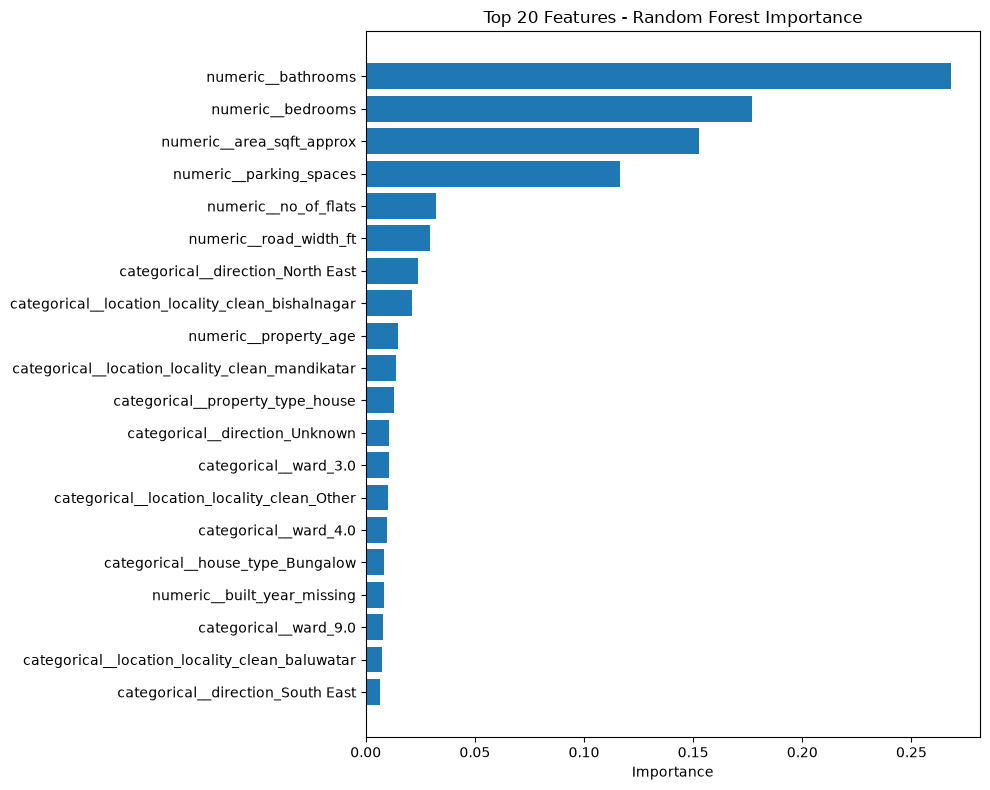

In [53]:
top20 = feature_importance.head(20).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top20["feature"], top20["importance"])
plt.xlabel("Importance")
plt.title("Top 20 Features - Random Forest Importance")
plt.tight_layout()
plt.show()

## 13. Permutation Importance

Run directly on the fitted pipeline against raw (un-encoded) columns, so results are reported per original feature rather than per one-hot dummy.

In [55]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    baseline_pipeline, X_test_final, y_test,
    n_repeats=10, random_state=42, scoring="neg_mean_absolute_error", n_jobs=-1,
)

permutation_importance_df = (
    pd.DataFrame({
        "feature": X_test_final.columns,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
print(permutation_importance_df.to_string(index=False))

                feature  importance_mean  importance_std
              bathrooms      9528.357233     4365.076409
               bedrooms      3292.271100     2706.758207
         parking_spaces      1631.535367     1493.836557
                   ward      1487.508533      832.504682
          property_type      1307.500550      678.873041
     built_year_missing      1306.466233      640.964130
              direction       870.335683     1625.517511
          road_width_ft       756.251417      997.709579
                   city       695.875033      302.566892
            no_of_flats       500.181567      828.602111
           property_age       269.026317     1054.103158
               kitchens        72.082917      166.109274
           living_rooms       -20.449917      348.632593
location_locality_clean       -51.325800     1778.439710
       area_sqft_approx       -74.589833     2049.273378
             house_type      -437.116317      680.878626


## 14. Hyperparameter Tuning (Random Forest)

Tunes the winning feature-set/target combination from Section 11. Parameter names are automatically prefixed for `TransformedTargetRegressor` when the log target was selected.

In [57]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_raw = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [0.5, 0.7, 1.0],
}
param_prefix = "model__regressor__" if best_use_log else "model__"
param_grid = {f"{param_prefix}{k}": v for k, v in param_grid_raw.items()}

tuning_pipeline = make_rf_pipeline(numeric_feats_final, categorical_feats_final, best_use_log)

rf_tuning = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf_tuning.fit(X_train_final, y_train)

print("Best parameters:", rf_tuning.best_params_)
print("Best CV MAE:", -rf_tuning.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.7, 'model__max_depth': 15}
Best CV MAE: 49676.234528142064


## 15. Final Selection: Baseline vs Tuned

Tuning optimizes CV MAE on training folds, which isn't guaranteed to win on the held-out test set. So rather than assume 'tuned' is automatically better, we compare both here and keep whichever actually performs best on the test set.

In [59]:
tuned_pipeline = rf_tuning.best_estimator_
tuned_preds = tuned_pipeline.predict(X_test_final)

mae_tuned = mean_absolute_error(y_test, tuned_preds)
rmse_tuned = np.sqrt(mean_squared_error(y_test, tuned_preds))
r2_tuned = r2_score(y_test, tuned_preds)

final_results = pd.DataFrame({
    "Model": [f"Random Forest - Baseline ({best_feature_set}, {best_combo['target']})",
              f"Random Forest - Tuned ({best_feature_set}, {best_combo['target']})"],
    "MAE": [mae, mae_tuned],
    "RMSE": [rmse, rmse_tuned],
    "R2": [r2, r2_tuned],
})
print(final_results.to_string(index=False))

if mae_tuned < mae:
    print("\nSelected: Tuned Random Forest (lower test MAE)")
    final_pipeline = tuned_pipeline
    selected_model_name = f"Random Forest - Tuned ({best_feature_set} features, {best_combo['target']} target)"
    selected_model_params = rf_tuning.best_params_
else:
    print("\nSelected: Baseline Random Forest (tuning did not improve test MAE)")
    final_pipeline = baseline_pipeline
    selected_model_name = f"Random Forest - Baseline ({best_feature_set} features, {best_combo['target']} target)"
    selected_model_params = {"n_estimators": 200, "random_state": 42, "n_jobs": -1}

final_preds = final_pipeline.predict(X_test_final)
print("\nFinal MAE :", mean_absolute_error(y_test, final_preds))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, final_preds)))
print("Final R2  :", r2_score(y_test, final_preds))

                                  Model          MAE         RMSE       R2
Random Forest - Baseline (base, normal) 55413.576833 82034.184161 0.492407
   Random Forest - Tuned (base, normal) 57719.702371 85285.838584 0.451370

Selected: Baseline Random Forest (tuning did not improve test MAE)

Final MAE : 55413.57683333333
Final RMSE: 82034.18416109151
Final R2  : 0.4924074887481462


## 16. Error Analysis

Now that `final_pipeline` and `final_preds` actually exist, look at the worst individual predictions to see whether errors are random noise or concentrated in a specific segment (a signal for future feature engineering).

In [61]:
error_df = X_test_final.copy()
error_df["actual_rent"] = y_test.values
error_df["predicted_rent"] = final_preds
error_df["error"] = error_df["predicted_rent"] - error_df["actual_rent"]
error_df["absolute_error"] = error_df["error"].abs()
error_df["percentage_error"] = (error_df["absolute_error"] / error_df["actual_rent"]) * 100

worst10 = error_df.sort_values("absolute_error", ascending=False).head(10)
print(worst10[["actual_rent", "predicted_rent", "error", "absolute_error", "percentage_error"]]
      .to_string(index=False))

 actual_rent  predicted_rent       error  absolute_error  percentage_error
    420000.0      146230.000 -273770.000      273770.000         65.183333
    450000.0      251554.995 -198445.005      198445.005         44.098890
    400000.0      243299.960 -156700.040      156700.040         39.175010
    350000.0      205182.490 -144817.510      144817.510         41.376431
    100000.0      170834.985   70834.985       70834.985         70.834985
     30000.0       95089.950   65089.950       65089.950        216.966500
    130000.0       67365.000  -62635.000       62635.000         48.180769
     70000.0      131854.990   61854.990       61854.990         88.364271
    120000.0      180875.000   60875.000       60875.000         50.729167
    150000.0      210004.960   60004.960       60004.960         40.003307


In [62]:
# Where are the worst errors concentrated?
for col in ["property_type", "city"]:
    print(f"\n===== Mean absolute error by {col} =====")
    print(error_df.groupby(col)["absolute_error"].agg(["mean", "count"]).sort_values("mean", ascending=False))


===== Mean absolute error by property_type =====
                       mean  count
property_type                     
house          72607.750526     19
flats          28040.011250      4
apartments     24385.714286      7

===== Mean absolute error by city =====
                   mean  count
city                          
Kathmandu  59624.894615     26
Lalitpur   58610.045000      1
Bhaktapur  17850.000000      3


## 17. Save the Final Model

The saved artifact is a single end-to-end `Pipeline` — preprocessing plus the model selected in Section 15 — so it can be loaded later and called directly with a raw feature `DataFrame`.

**Note:** this pipeline expects the *engineered* feature set from Sections 5–7 (`property_age`, `built_year_missing`, `parking_spaces`, `location_locality_clean`, and — if the experimental feature set won — `furnishing_status`/`has_garden`), not the raw scraped columns. Re-run the Section 5–7 cleaning/feature-engineering steps on any brand-new raw listings before scoring them.

In [64]:
import joblib
import json
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "rent_prediction_pipeline.joblib"
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Saved pipeline to: {MODEL_PATH.resolve()}")

metadata = {
    "target": target,
    "numeric_features": numeric_feats_final,
    "categorical_features": categorical_feats_final,
    "feature_set": best_feature_set,
    "log_target": bool(best_use_log),
    "current_bs_year": CURRENT_BS_YEAR,
    "selected_model": selected_model_name,
    "selected_model_params": selected_model_params,
    "test_mae": mean_absolute_error(y_test, final_preds),
    "test_rmse": float(np.sqrt(mean_squared_error(y_test, final_preds))),
    "test_r2": r2_score(y_test, final_preds),
}
METADATA_PATH = MODEL_DIR / "model_metadata.json"
with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved metadata to: {METADATA_PATH.resolve()}")

Saved pipeline to: C:\Users\sampada\Predicting Fair Rental Prices in Kathmandu Valley\models\rent_prediction_pipeline.joblib
Saved metadata to: C:\Users\sampada\Predicting Fair Rental Prices in Kathmandu Valley\models\model_metadata.json


## 18. Predict Rent

In [66]:
def predict_rent(feature_dict, pipeline=final_pipeline):
    """Predict monthly rent (NPR) from a dict of already-engineered feature values.

    Required keys: whatever is in `numeric_feats_final + categorical_feats_final`
    (printed below) — this adapts automatically to whichever feature set won in
    Section 11.
    """
    row = pd.DataFrame([feature_dict])[numeric_feats_final + categorical_feats_final]
    return float(pipeline.predict(row)[0])

print("Required feature keys:", numeric_feats_final + categorical_feats_final)

# Example usage
sample = X_test_final.iloc[0].to_dict()
print("\nPredicted rent (NPR):", predict_rent(sample))
print("Actual rent (NPR)   :", y_test.iloc[0])

Required feature keys: ['area_sqft_approx', 'road_width_ft', 'bedrooms', 'bathrooms', 'living_rooms', 'kitchens', 'no_of_flats', 'property_age', 'parking_spaces', 'built_year_missing', 'ward', 'property_type', 'house_type', 'direction', 'city', 'location_locality_clean']

Predicted rent (NPR): 131109.87
Actual rent (NPR)   : 95000.0


In [104]:
def predict_rent_with_interval(feature_dict, pipeline=final_pipeline, lower_pct=10, upper_pct=90):
    """Predict monthly rent (NPR) with a prediction interval, using the spread of
    individual tree predictions inside the Random Forest as an uncertainty estimate.

    Returns {"point": ..., "lower": ..., "upper": ..., "n_trees": ...}.
    """
    row = pd.DataFrame([feature_dict])[numeric_feats_final + categorical_feats_final]

    preprocessor_step = pipeline.named_steps["preprocessor"]
    model_step = pipeline.named_steps["model"]
    row_transformed = preprocessor_step.transform(row)

    is_log_target = isinstance(model_step, TransformedTargetRegressor)
    inner_rf = model_step.regressor_ if is_log_target else model_step

    tree_preds = np.array([tree.predict(row_transformed) for tree in inner_rf.estimators_]).flatten()
    if is_log_target:
        tree_preds = model_step.inverse_func(tree_preds)

    return {
        "point": float(pipeline.predict(row)[0]),
        "lower": float(np.percentile(tree_preds, lower_pct)),
        "upper": float(np.percentile(tree_preds, upper_pct)),
        "n_trees": len(tree_preds),
    }


sample = X_test_final.iloc[0].to_dict()
result = predict_rent_with_interval(sample)
print(f"Point estimate: {result['point']:,.0f} NPR")
print(f"80% interval  : {result['lower']:,.0f} - {result['upper']:,.0f} NPR (based on {result['n_trees']} trees)")
print(f"Actual rent   : {y_test.iloc[0]:,.0f} NPR")

Point estimate: 131,110 NPR
80% interval  : 79,500 - 200,000 NPR (based on 200 trees)
Actual rent   : 95,000 NPR


In [106]:
coverage_hits = 0
interval_widths = []

for i in range(len(X_test_final)):
    row_dict = X_test_final.iloc[i].to_dict()
    result = predict_rent_with_interval(row_dict)
    actual = y_test.iloc[i]
    if result["lower"] <= actual <= result["upper"]:
        coverage_hits += 1
    interval_widths.append(result["upper"] - result["lower"])

coverage_rate = coverage_hits / len(X_test_final) * 100
print(f"80% interval coverage on test set: {coverage_rate:.1f}% ({coverage_hits}/{len(X_test_final)} listings)")
print(f"Average interval width: {np.mean(interval_widths):,.0f} NPR")

80% interval coverage on test set: 80.0% (24/30 listings)
Average interval width: 131,593 NPR


In [109]:
import sys
print(sys.executable)

import sklearn
import pandas
import numpy
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)

C:\Anaconda\python.exe
Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
scikit-learn: 1.9.0
pandas: 3.0.5
numpy: 2.5.1
joblib: 1.5.3


In [111]:
print("Selected feature set:", best_feature_set)
print("Using log target:", best_use_log)
print("Numeric features:", numeric_feats_final)
print("Categorical features:", categorical_feats_final)
print("Final pipeline:")
print(final_pipeline)

Selected feature set: base
Using log target: False
Numeric features: ['area_sqft_approx', 'road_width_ft', 'bedrooms', 'bathrooms', 'living_rooms', 'kitchens', 'no_of_flats', 'property_age', 'parking_spaces', 'built_year_missing']
Categorical features: ['ward', 'property_type', 'house_type', 'direction', 'city', 'location_locality_clean']
Final pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['area_sqft_approx',
                                                   'road_width_ft', 'bedrooms',
                                                   'bathrooms', 'living_rooms',
                                                   'kitchens', 'no_of_flats',
                                                   'proper

In [113]:
import joblib

loaded_pipeline = joblib.load("models/rent_prediction_pipeline.joblib")

print(loaded_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['area_sqft_approx',
                                                   'road_width_ft', 'bedrooms',
                                                   'bathrooms', 'living_rooms',
                                                   'kitchens', 'no_of_flats',
                                                   'property_age',
                                                   'parking_spaces',
                                                   'built_year_missing']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                             

In [117]:
for col in X.columns:
  print(col)

area_sqft_approx
bathrooms
bedrooms
built_year_missing
city
direction
furnishing_status
has_garden
house_type
kitchens
living_rooms
location_locality_clean
no_of_flats
parking_spaces
property_age
property_type
road_width_ft
ward
